# **New York City Yellow Taxi Data**

## **Problem Statement**
The objective of this analysis is to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, we will only be using the data from 2023.

The data for each month is present in a different parquet file. We will use twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.



## Data Preparation



### Import Libraries

In [189]:
# Import warnings
import warnings
warnings.filterwarnings("ignore")


In [190]:
# Import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [191]:
# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.3.5
pandas version: 2.3.3
matplotlib version: 3.10.6
seaborn version: 0.13.2


### Load the dataset


In [192]:
# Try loading one file
df_ = pd.read_parquet("2023-1.parquet")
df_.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

In [37]:
import os
import glob

# Select the folder having data files
os.chdir(r"C:\\Users\\Mukul\\Downloads\\Upgrad Course\\Data Toolkit\\EDA NYC Taxi Analysis\\Datasets and Dictionary\\trip_records")

#Define sampling fraction
sample_fraction = 0.01

# Create a list of all the twelve files to read
file_list = glob.glob("2023-*.parquet")


# initialise an empty list
final_df_list = []


# iterate through the list of files and sample one by one:
for file in file_list:
    try:
        print(f"Processing {file}")
        
        df_month = pd.read_parquet(file)     # Reading the current file
        
        df_month = df_month[(df_month['tpep_pickup_datetime'].dt.year == 2023)]
        
        df_month["pickup_date"] = df_month["tpep_pickup_datetime"].dt.date
        df_month["pickup_hour"] = df_month["tpep_pickup_datetime"].dt.hour   
        
        
        grouped = df_month.groupby(["pickup_date", "pickup_hour"])
        
        
        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        
        # After completing iteration through each date, we will append this data to the final dataframe.
        
        
        # Loop through dates and then loop through every hour of each date
        
        for (date, hour), group in grouped:
            sampled_group = group.sample(frac=sample_fraction, random_state=42)
            final_df_list.append(sampled_group)
            
            # Concatenate the sampled data of all the dates to a single dataframe
    
    except Exception as e:
        print(f"Error reading file {file}: {e}")

df = pd.concat(final_df_list, ignore_index = True) #This df was initiated above 

Processing 2023-1.parquet
Processing 2023-10.parquet
Processing 2023-11.parquet
Processing 2023-12.parquet
Processing 2023-2.parquet
Processing 2023-3.parquet
Processing 2023-4.parquet
Processing 2023-5.parquet
Processing 2023-6.parquet
Processing 2023-7.parquet
Processing 2023-8.parquet
Processing 2023-9.parquet


In [38]:
# Store the df in csv/parquet
df.to_parquet("final_sampled.parquet", index = False)

## Data Cleaning


In [193]:
# Load the new data file
df = pd.read_parquet("final_sampled.parquet")

In [194]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_date,pickup_hour,Airport_fee
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,...,0.5,0.00,0.0,1.0,41.15,0.0,1.25,2023-01-01,0,NaN
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,0.5,2.58,0.0,1.0,15.48,2.5,0.00,2023-01-01,0,NaN
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,...,0.5,0.00,0.0,1.0,16.40,2.5,0.00,2023-01-01,0,NaN
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,...,0.5,0.00,0.0,1.0,11.50,2.5,0.00,2023-01-01,0,NaN
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,...,0.5,5.93,0.0,1.0,35.57,NaN,NaN,2023-01-01,0,NaN


In [195]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 379268 entries, 0 to 379267
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               379268 non-null  int64         
 1   tpep_pickup_datetime   379268 non-null  datetime64[us]
 2   tpep_dropoff_datetime  379268 non-null  datetime64[us]
 3   passenger_count        366326 non-null  float64       
 4   trip_distance          379268 non-null  float64       
 5   RatecodeID             366326 non-null  float64       
 6   store_and_fwd_flag     366326 non-null  object        
 7   PULocationID           379268 non-null  int64         
 8   DOLocationID           379268 non-null  int64         
 9   payment_type           379268 non-null  int64         
 10  fare_amount            379268 non-null  float64       
 11  extra                  379268 non-null  float64       
 12  mta_tax                379268 non-null  floa

#### Fixing Columns


In [196]:
# Fix the index and drop any columns that are not needed
df.reset_index(drop=True, inplace=True)
df.drop(columns = ["pickup_date"], inplace = True)

In [197]:
# Combine the two airport fee columns
df["airport_fee"] = df["airport_fee"].fillna(df["Airport_fee"])
df.drop(columns = ["Airport_fee"], inplace = True)

In [198]:
# check where values of fare amount are negative
df[df["fare_amount"] < 0]   #There are no neagtive values in fare_amount column

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour


In [199]:
# Analyse RatecodeID for the negative fare amounts
df["RatecodeID"].describe() #There are no negative fare amount values

count    366326.000000
mean          1.644642
std           7.460939
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          99.000000
Name: RatecodeID, dtype: float64

In [200]:
# Find which columns have negative values
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour
count,379268.000000,379268,379268,366326.000000,379268.000000,366326.000000,379268.000000,379268.000000,379268.000000,379268.000000,379268.000000,379268.000000,379268.000000,379268.000000,379268.000000,379268.000000,366326.000000,366326.000000,379268.000000
mean,1.734193,2023-07-02 20:10:08.512408,2023-07-02 20:27:28.460094,1.367187,3.611285,1.644642,165.262672,163.989997,1.163394,20.175333,1.582689,0.495354,3.540784,0.589633,0.998977,29.222007,2.308804,0.141878,14.264818
min,1.000000,2023-01-01 00:04:34,2023-01-01 00:09:40,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,-2.500000,-0.500000,0.000000,0.000000,-1.000000,-5.750000,-2.500000,-1.750000,0.000000
25%,1.000000,2023-04-02 16:26:38.750000,2023-04-02 16:44:00.250000,1.000000,1.050000,1.000000,132.000000,113.000000,1.000000,9.300000,0.000000,0.500000,1.000000,0.000000,1.000000,15.960000,2.500000,0.000000,11.000000
50%,2.000000,2023-06-27 16:07:21.500000,2023-06-27 16:21:37.500000,1.000000,1.790000,1.000000,162.000000,162.000000,1.000000,13.500000,1.000000,0.500000,2.850000,0.000000,1.000000,21.000000,2.500000,0.000000,15.000000
75%,2.000000,2023-10-06 19:39:01,2023-10-06 19:53:23.250000,1.000000,3.400000,1.000000,234.000000,234.000000,1.000000,21.900000,2.500000,0.500000,4.420000,0.000000,1.000000,30.750000,2.500000,0.000000,19.000000
max,6.000000,2023-12-31 23:54:03,2024-01-01 20:14:57,9.000000,22528.820000,99.000000,265.000000,265.000000,4.000000,143163.450000,14.250000,4.000000,150.290000,143.000000,1.000000,143167.450000,2.500000,1.750000,23.000000
std,0.447397,NaN,NaN,0.890815,49.391070,7.460939,64.020218,69.772137,0.507365,233.143157,1.821118,0.048617,4.024369,2.175130,0.031027,233.532444,0.664662,0.463218,5.807372


In [201]:
# fix these negative values
df = df[df["extra"] >= 0]
df = df[df["mta_tax"] >= 0]
df = df[df["improvement_surcharge"] >= 0]
df = df[df["total_amount"] >= 0]
df = df[df["congestion_surcharge"] >= 0]
df = df[df["airport_fee"] >= 0]

In [202]:
df.shape

(366310, 20)

### Handling Missing Values


In [203]:
# Find the proportion of missing values in each column
df.isnull().sum()

#When we merged the airport columns and removed negative values from all columns then null was removed along with that so there are no null values.

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
airport_fee              0
pickup_hour              0
dtype: int64


Handling missing values in `passenger_count`

In [204]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'
(df["passenger_count"] == 0).sum()
df = df[df["passenger_count"] > 0]

Handle missing values in `RatecodeID`

In [205]:
# Fix missing values in 'RatecodeID'
df["RatecodeID"].isnull().sum() 

#There are no missing values in RatecodeID column after performing above steps

np.int64(0)


Impute NaN in `congestion_surcharge`

In [206]:
# handle null values in congestion_surcharge

df["congestion_surcharge"].isnull().sum()

#There are no missing values in congestion_surcharge column after performing above steps

np.int64(0)

In [207]:
# Handle any remaining missing values
(df["trip_distance"] == 0).sum()


np.int64(4371)

### Handling Outliers


In [208]:
# Describe the data and check if there are any potential outliers present

df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour
count,360486.000000,360486,360486,360486.000000,360486.000000,360486.000000,360486.000000,360486.000000,360486.000000,360486.000000,360486.000000,360486.000000,360486.000000,360486.000000,360486.000000,360486.000000,360486.000000,360486.000000,360486.000000
mean,1.749233,2023-07-02 00:56:25.991048,2023-07-02 01:13:44.499914,1.389277,3.498561,1.652697,165.381724,164.214608,1.203686,20.142660,1.606678,0.495436,3.577469,0.592757,0.999347,29.267858,2.308717,0.142768,14.304292
min,1.000000,2023-01-01 00:04:34,2023-01-01 00:09:40,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,2023-04-01 23:04:29,2023-04-01 23:20:36,1.000000,1.060000,1.000000,132.000000,113.000000,1.000000,9.300000,0.000000,0.500000,1.000000,0.000000,1.000000,15.960000,2.500000,0.000000,11.000000
50%,2.000000,2023-06-26 12:54:57.500000,2023-06-26 13:09:57.500000,1.000000,1.790000,1.000000,162.000000,162.000000,1.000000,13.500000,1.000000,0.500000,2.860000,0.000000,1.000000,21.000000,2.500000,0.000000,15.000000
75%,2.000000,2023-10-05 22:25:48.750000,2023-10-05 22:46:53.500000,1.000000,3.360000,1.000000,234.000000,234.000000,1.000000,21.900000,2.500000,0.500000,4.450000,0.000000,1.000000,30.700000,2.500000,0.000000,19.000000
max,2.000000,2023-12-31 23:54:03,2024-01-01 20:14:57,9.000000,9678.780000,99.000000,265.000000,265.000000,4.000000,143163.450000,14.250000,4.000000,150.290000,143.000000,1.000000,143167.450000,2.500000,1.750000,23.000000
std,0.433455,NaN,NaN,0.880744,23.232802,7.511854,63.712350,69.742837,0.464780,239.115615,1.821197,0.048013,4.046778,2.179106,0.023749,239.502690,0.664545,0.464495,5.781182


In [209]:
df.shape

(360486, 20)

In [210]:
# removing trip_distance and fare_amount where it is 0
 
df = df[df["trip_distance"] > 0]
df = df[df["fare_amount"] > 0]

Remove 7+ passenger counts as there are very less instances.

In [211]:
# remove passenger_count > 6 
df = df[df["passenger_count"] <= 6]

In [212]:
df = df[df["trip_distance"] < 100]

In [213]:
df = df[df['fare_amount'] < 400]

In [214]:
df = df[df['RatecodeID'] != 99]  # removed rows where RatecodeID = 99 which is not incorrect as per the data standard, which accounts for around 0.5% of the data. 

In [216]:
df.shape

(354128, 20)

## Exploratory Data Analysis


In [217]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'pickup_hour']

#### General EDA: Finding Patterns and Trends


##### Temporal Analysis

In [218]:
# Find and show the hourly trends in taxi pickups
hourly_trips = df.groupby("pickup_hour").size()
hourly_trips

pickup_hour
0      9957
1      6637
2      4350
3      2828
4      1769
5      1804
6      4577
7      9355
8     13067
9     15018
10    16417
11    17828
12    19402
13    20069
14    21548
15    22080
16    22061
17    24003
18    25117
19    22600
20    20207
21    20150
22    18650
23    14634
dtype: int64

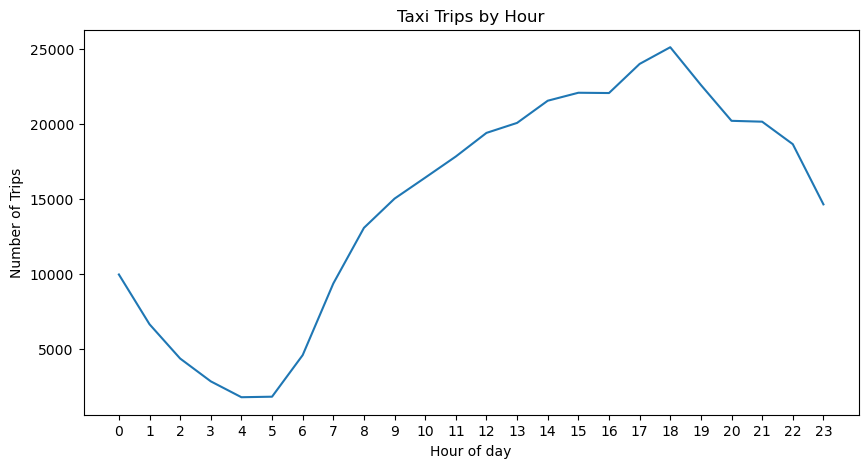

In [219]:
plt.figure(figsize=(10,5))
plt.plot(hourly_trips.index, hourly_trips.values)
plt.title("Taxi Trips by Hour")
plt.xlabel("Hour of day")
plt.ylabel("Number of Trips")
plt.xticks(range(0,24))
plt.show()

In [220]:
# Find and show the daily trends in taxi pickups (days of the week)
df["day_of_week"] = df["tpep_pickup_datetime"].dt.day_name()
daily_trips = df.groupby("day_of_week").size()

In [221]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

daily_trips = daily_trips.reindex(order)
daily_trips

day_of_week
Monday       44096
Tuesday      51430
Wednesday    54446
Thursday     55660
Friday       52374
Saturday     51543
Sunday       44579
dtype: int64

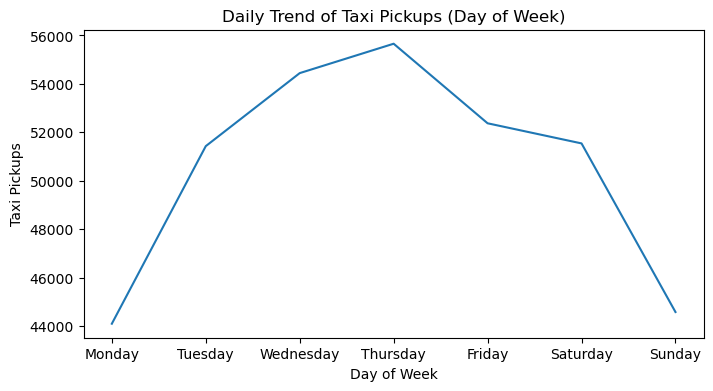

In [222]:
plt.figure(figsize=(8,4))
plt.plot(daily_trips.index, daily_trips.values)
plt.title("Daily Trend of Taxi Pickups (Day of Week)")
plt.xlabel("Day of Week")
plt.ylabel("Taxi Pickups")
plt.show()

In [223]:
# Show the monthly trends in pickups
df["month"] = df["tpep_pickup_datetime"].dt.month_name()

In [224]:
monthly_trips = df.groupby("month").size()

In [225]:
order = ['January','February','March','April','May','June',
         'July','August','September','October','November','December']
monthly_trips = monthly_trips.reindex(order)
monthly_trips

month
January      28709
February     27228
March        31640
April        30714
May          32580
June         30790
July         26981
August       26069
September    25876
October      32326
November     30717
December     30498
dtype: int64

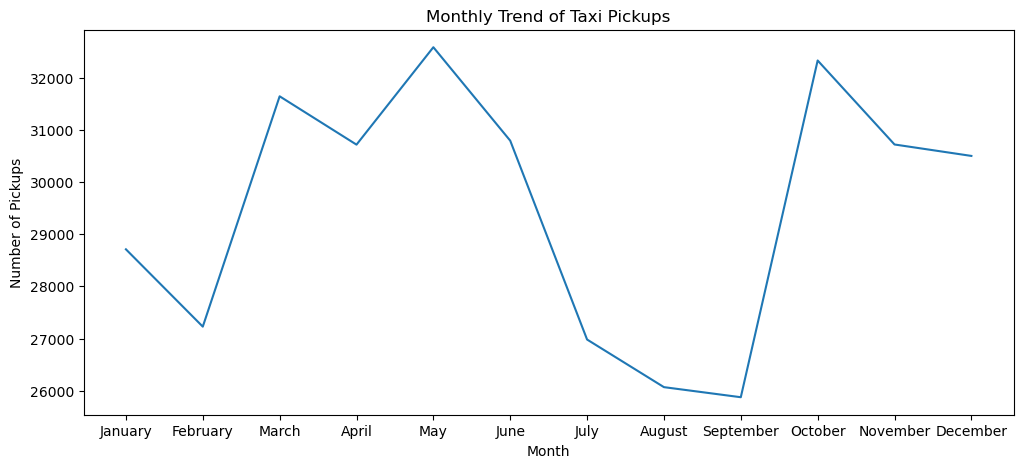

In [226]:
plt.figure(figsize=(12,5))
plt.plot(monthly_trips.index, monthly_trips.values)
plt.title("Monthly Trend of Taxi Pickups")
plt.xlabel("Month")
plt.ylabel("Number of Pickups")
plt.show()

##### Financial Analysis

In [227]:
df[["fare_amount", "tip_amount", "total_amount", "trip_distance"]].describe()


,fare_amount,tip_amount,total_amount,trip_distance
count,354128.000000,354128.000000,354128.000000,354128.000000
mean,19.537261,3.600440,28.718487,3.463104
std,17.710745,3.988718,22.418768,4.507693
min,0.010000,0.000000,1.010000,0.010000
25%,9.300000,1.000000,15.960000,1.080000
50%,13.500000,2.880000,21.000000,1.800000
75%,21.900000,4.480000,30.600000,3.380000
max,386.600000,150.290000,473.580000,76.730000


In [228]:
df.shape

(354128, 22)

In [229]:
## It is beneficial to remove trip_distance and fair_amount where they are zero as they represent invalid trips.
## But tip_amount having zero is normal and can create a biased result towards tipped trips if removed.
## So it should not be removed.

In [230]:
# Create a df with non zero entries for the selected parameters.
df_non_zero = df[(df["fare_amount"] > 0)&
(df["total_amount"] > 0)&
(df["trip_distance"] > 0)]

In [231]:
(df_non_zero["tip_amount"] == 0).sum()  

# We can see that there are more than 75000 rows where the tip amount is equal to zero. So it will create
# a bias if we remove them so it is kept as it is to maintain the data validity.

np.int64(75518)

In [232]:
# Group data by month and analyse monthly revenue

monthly_revenue = df_non_zero.groupby("month")["total_amount"].sum()
monthly_revenue

month
April        875794.33
August       753812.45
December     879247.34
February     742404.10
January      783890.58
July         773474.56
June         894722.94
March        888582.51
May          952303.61
November     884801.65
October      962059.33
September    778926.85
Name: total_amount, dtype: float64

In [233]:
order = ['January','February','March','April','May','June',
         'July','August','September','October','November','December']
monthly_revenue = monthly_revenue.reindex(order)
monthly_revenue

month
January      783890.58
February     742404.10
March        888582.51
April        875794.33
May          952303.61
June         894722.94
July         773474.56
August       753812.45
September    778926.85
October      962059.33
November     884801.65
December     879247.34
Name: total_amount, dtype: float64

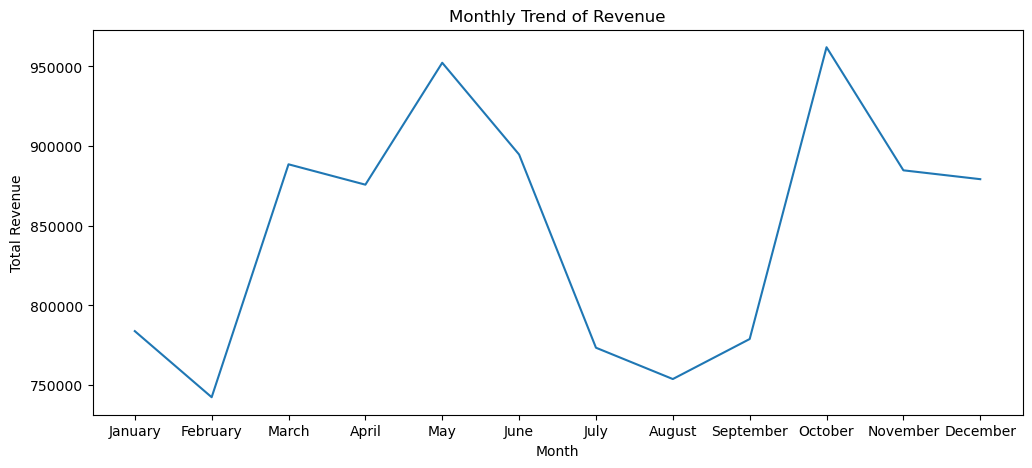

In [234]:
plt.figure(figsize=(12,5))
plt.plot(monthly_revenue.index, monthly_revenue.values)
plt.title("Monthly Trend of Revenue")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.show()

In [235]:
# Calculate proportion of each quarter

df["quarter"] = df["tpep_pickup_datetime"].dt.quarter

In [236]:
df_non_zero["quarter"] = df_non_zero["tpep_pickup_datetime"].dt.quarter

In [237]:
quarter_revenue = df_non_zero.groupby("quarter")["total_amount"].sum()
quarter_revenue

quarter
1    2414877.19
2    2722820.88
3    2306213.86
4    2726108.32
Name: total_amount, dtype: float64

In [238]:
quarter_proportion = quarter_revenue/quarter_revenue.sum()*100
quarter_proportion.round(2)

quarter
1    23.75
2    26.77
3    22.68
4    26.81
Name: total_amount, dtype: float64

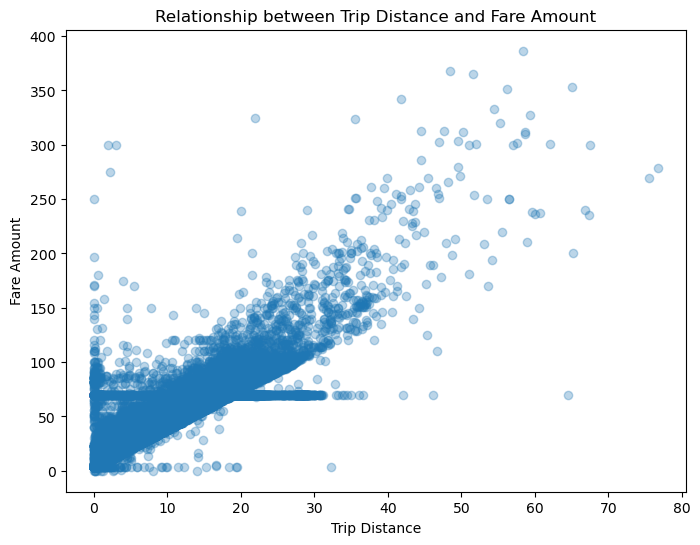

In [239]:
# Show how trip fare is affected by distance

plt.figure(figsize=(8,6))
plt.scatter(df_non_zero['trip_distance'], df_non_zero['fare_amount'], alpha=0.3)
plt.title("Relationship between Trip Distance and Fare Amount")
plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")
plt.show()

In [240]:
df_non_zero['trip_distance'].corr(df_non_zero['fare_amount'])

np.float64(0.9474887300351755)

In [241]:
# Show relationship between fare and trip duration

df_non_zero['trip_duration'] = (df_non_zero['tpep_dropoff_datetime'] - df_non_zero['tpep_pickup_datetime']).dt.total_seconds() / 60

In [242]:
# we were having -ve values in trip duration so we have to filter them

In [243]:
df_non_zero = df_non_zero[(df_non_zero['trip_duration'] > 0) & (df_non_zero['trip_duration'] <= 180)]

In [244]:
corr_duration = df_non_zero["fare_amount"].corr(df_non_zero["trip_duration"])
corr_duration

np.float64(0.8547474780779902)

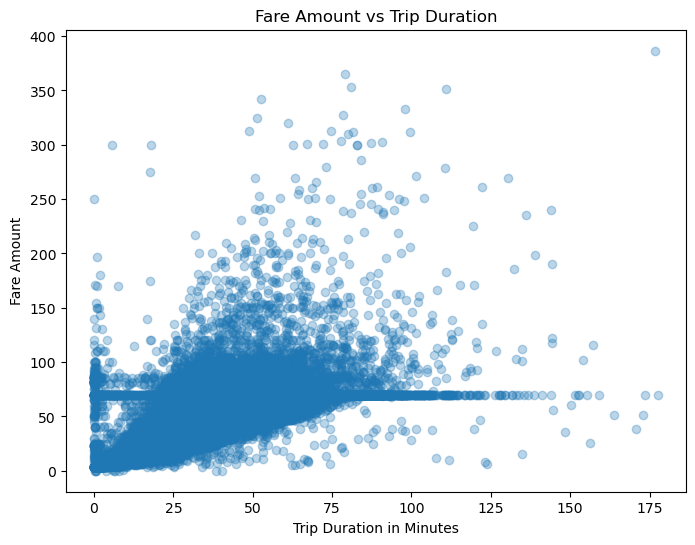

In [245]:
# Fare Amount Vs Trip Duration

plt.figure(figsize=(8,6))
plt.scatter(df_non_zero["trip_duration"], df_non_zero["fare_amount"], alpha = 0.3)
plt.title("Fare Amount vs Trip Duration") 
plt.xlabel("Trip Duration in Minutes")
plt.ylabel("Fare Amount")
plt.show()

In [246]:
# Show relationship between fare and number of passengers

corr_passenger = df_non_zero["fare_amount"].corr(df_non_zero["passenger_count"])
corr_passenger

np.float64(0.0438576486713885)

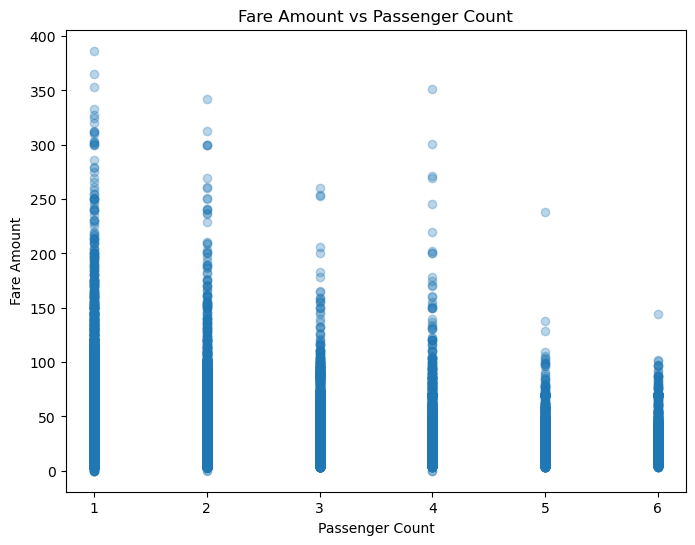

In [247]:
# Fare Amount vs Passenger Count

plt.figure(figsize=(8,6))
plt.scatter(df_non_zero["passenger_count"], df_non_zero["fare_amount"], alpha = 0.3)
plt.title("Fare Amount vs Passenger Count") 
plt.xlabel("Passenger Count")
plt.ylabel("Fare Amount")
plt.show()

In [248]:
# Show relationship between tip and trip distance

corr_tip_distance = df_non_zero["tip_amount"].corr(df_non_zero["trip_distance"])
corr_tip_distance

np.float64(0.6026322873334594)

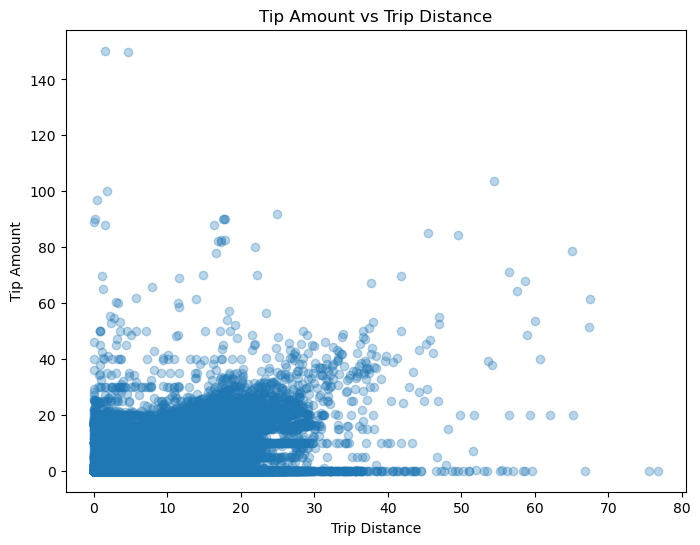

In [249]:
# Tip Amount vs Trip Distance

plt.figure(figsize=(8,6))
plt.scatter(df_non_zero["trip_distance"], df_non_zero["tip_amount"], alpha = 0.3)
plt.title("Tip Amount vs Trip Distance") 
plt.xlabel("Trip Distance")
plt.ylabel("Tip Amount")
plt.show()

In [250]:
# Analyse the distribution of different payment types (payment_type).
payment_map = {1: "Credit Card", 2: "Cash", 3: "No Charge", 4: "Dispute", 5: "Unknown", 6: "Voided"}

df_non_zero['payment_type_name'] = df_non_zero['payment_type'].map(payment_map)

In [251]:
payment_percentage = df_non_zero["payment_type_name"].value_counts(normalize = True)*100
payment_percentage

payment_type_name
Credit Card    81.792332
Cash           17.187275
Dispute         0.684597
No Charge       0.335797
Name: proportion, dtype: float64

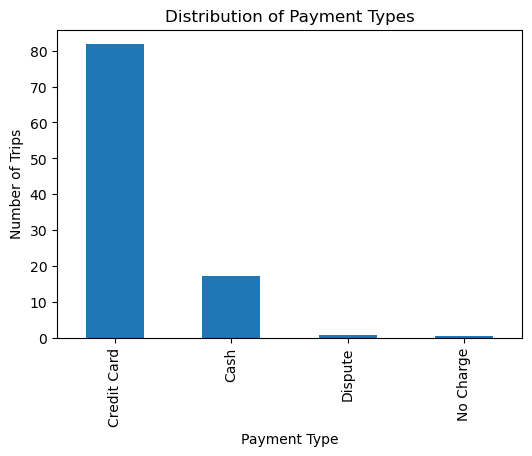

In [252]:
payment_percentage.plot(kind='bar', figsize=(6,4))
plt.title("Distribution of Payment Types")
plt.xlabel("Payment Type")
plt.ylabel("Number of Trips")
plt.show()

##### Geographical Analysis

In [253]:
# !pip install geopandas
!pip install geopandas

In [254]:
# import geopandas as gpd
import geopandas as gpd

# Read the shapefile using geopandas
zones = gpd.read_file("taxi_zones.shp")# read the .shp file using gpd
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


In [255]:
print(zones.info())

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


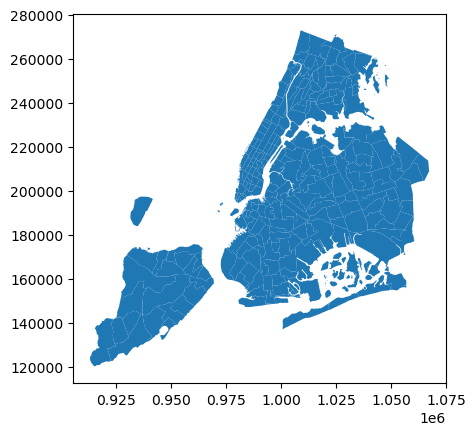

In [256]:
zones.plot()
plt.show()

In [257]:
# Merge zones and trip records using locationID and PULocationID

zones["LocationID"].value_counts().head()

LocationID
103    3
56     2
1      1
176    1
181    1
Name: count, dtype: int64

In [258]:
# We will dissolve the locationID from zones to handle duplicates

zones_unique = zones.dissolve(by = "LocationID").reset_index()

In [259]:
trip_zone_df = df_non_zero.merge(zones_unique, left_on = "PULocationID", right_on = "LocationID", how = "left")

In [260]:
trip_zone_df = trip_zone_df[trip_zone_df["zone"].notnull()]

In [261]:
trip_zone_df.shape

(350649, 32)

In [262]:
# Group data by location and calculate the number of trips

location_trip_count = trip_zone_df.groupby("PULocationID").size().reset_index(name = "trip_counts")
location_trip_count

,PULocationID,trip_counts
0,1,8
1,4,338
2,6,4
3,7,131
4,9,2
...,...,...
193,258,1
194,260,52
195,261,1838
196,262,4530


In [264]:
# Merge trip counts back to the zones GeoDataFrame

zones_trip_df = zones_unique.merge(location_trip_count, left_on = "LocationID", right_on = "PULocationID", how = "left")
zones_trip_df.head()

,LocationID,geometry,OBJECTID,Shape_Leng,Shape_Area,zone,borough,PULocationID,trip_counts
0,1,"POLYGON ((933100.918 192536.086, 933091.011 19...",1,0.116357,0.000782,Newark Airport,EWR,1.0,8.0
1,2,"MULTIPOLYGON (((1020447.262 151454.148, 102035...",2,0.433470,0.004866,Jamaica Bay,Queens,NaN,NaN
2,3,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",3,0.084341,0.000314,Allerton/Pelham Gardens,Bronx,NaN,NaN
3,4,"POLYGON ((992073.467 203714.076, 992068.667 20...",4,0.043567,0.000112,Alphabet City,Manhattan,4.0,338.0
4,5,"POLYGON ((935843.31 144283.336, 936046.565 144...",5,0.092146,0.000498,Arden Heights,Staten Island,NaN,NaN


In [265]:
zones_trip_df["trip_counts"] = zones_trip_df["trip_counts"].fillna(0)

In [266]:
zones_trip_df.shape

(260, 9)

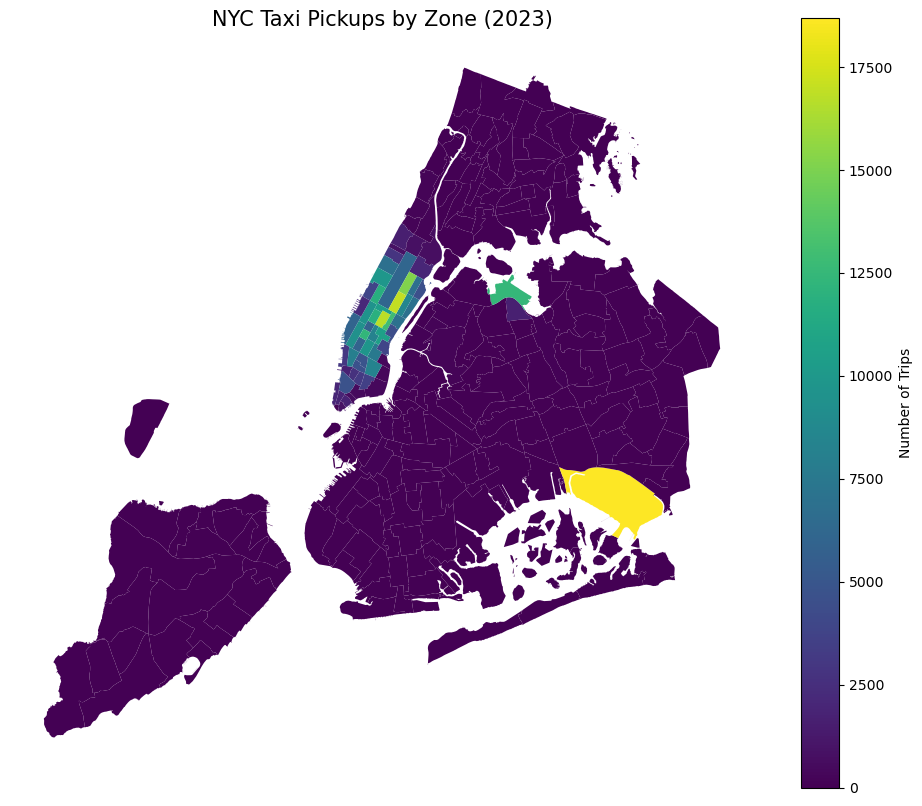

In [267]:
# Define figure and axis

fig, ax = plt.subplots(1, 1, figsize = (12, 10))


zones_trip_df.plot(
column = "trip_counts",
ax = ax,
legend = True,
legend_kwds = {'label': "Number of Trips", 'orientation': "vertical"}
)

ax.set_title("NYC Taxi Pickups by Zone (2023)", fontsize=15)
ax.axis('off')
plt.show()

In [268]:
# Displaying the zones DF sorted by the number of trips

zone_trip_sorted = zones_trip_df.sort_values("trip_counts", ascending = False)

In [269]:
zone_trip_sorted[["LocationID", "zone", "borough", "trip_counts"]].head(10)

,LocationID,zone,borough,trip_counts
128,132,JFK Airport,Queens,18698.0
233,237,Upper East Side South,Manhattan,16986.0
157,161,Midtown Center,Manhattan,16741.0
232,236,Upper East Side North,Manhattan,15154.0
158,162,Midtown East,Manhattan,12917.0
134,138,LaGuardia Airport,Queens,12475.0
182,186,Penn Station/Madison Sq West,Manhattan,12312.0
226,230,Times Sq/Theatre District,Manhattan,11872.0
138,142,Lincoln Square East,Manhattan,11779.0
166,170,Murray Hill,Manhattan,10568.0


#### Detailed EDA: Insights and Strategies


##### Operational Efficiency

In [270]:
# Find routes which have the slowest speeds at different times of the day

trip_zone_df["route"] = trip_zone_df["PULocationID"].astype(str) + " - " + trip_zone_df["DOLocationID"].astype(str)

In [271]:
trip_zone_df["trip_duration_hr"] = trip_zone_df["trip_duration"] / 60

In [272]:
route_hourly = trip_zone_df.groupby(["route", "pickup_hour"]).agg({"trip_distance":"mean", "trip_duration_hr":"mean", "route":"count"}).rename(columns={"route":"trip_count"}).reset_index()

In [273]:
# filter routes which have less trips to get correct analysis

route_hourly = route_hourly[route_hourly["trip_count"] >= 5]

In [274]:
route_hourly["speed_hourly"] = route_hourly["trip_distance"]/route_hourly["trip_duration_hr"]

In [275]:
slow_routes = route_hourly.loc[route_hourly.groupby("pickup_hour")["speed_hourly"].idxmin()]
slow_routes

,route,pickup_hour,trip_distance,trip_duration_hr,trip_count,speed_hourly
26363,162 - 48,0,1.280000,0.237639,6,5.386324
20776,148 - 148,1,0.366000,0.156917,10,2.332448
19421,144 - 144,2,0.341667,0.059167,6,5.774648
48353,246 - 186,3,0.746000,0.118000,5,6.322034
37629,230 - 230,4,1.094000,0.161667,5,6.767010
32698,186 - 246,5,0.936000,0.094611,5,9.893130
43405,236 - 262,6,0.794000,0.125611,5,6.321097
25553,162 - 161,7,0.618462,0.122051,13,5.067227
31657,186 - 100,8,0.635556,0.158148,9,4.018735
37634,230 - 230,9,0.720000,0.182130,6,3.953228


In [276]:
# Visualise the number of trips per hour and find the busiest hour

trips_per_hour = trip_zone_df.groupby("pickup_hour").size()
trips_per_hour

pickup_hour
0      9845
1      6564
2      4292
3      2804
4      1745
5      1782
6      4535
7      9266
8     12939
9     14858
10    16274
11    17664
12    19239
13    19871
14    21342
15    21869
16    21844
17    23756
18    24856
19    22389
20    20011
21    19936
22    18470
23    14498
dtype: int64

In [277]:
busiest_hour = trips_per_hour.idxmax()
busiest_hour

np.int32(18)

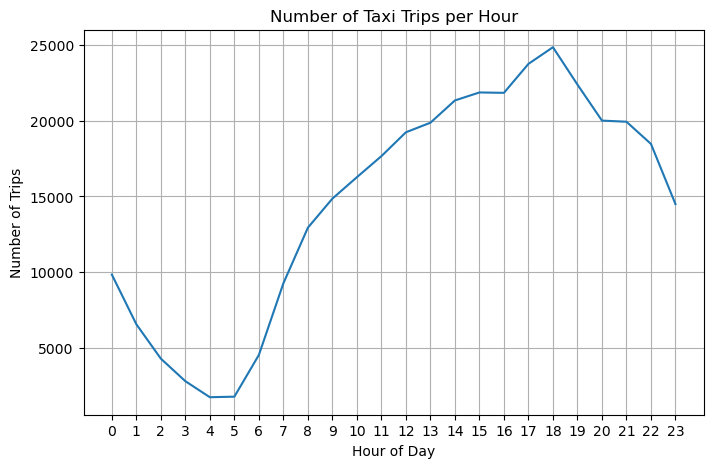

In [278]:
plt.figure(figsize=(8,5))
plt.plot(trips_per_hour.index, trips_per_hour.values)
plt.title("Number of Taxi Trips per Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.xticks(range(0,24))
plt.grid(True)
plt.show()

In [279]:
top5_busiest = trips_per_hour.sort_values(ascending=False).head(5)
top5_busiest

pickup_hour
18    24856
17    23756
19    22389
15    21869
16    21844
dtype: int64

In [280]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.01

top5_actual = top5_busiest / sample_fraction
top5_actual

pickup_hour
18    2485600.0
17    2375600.0
19    2238900.0
15    2186900.0
16    2184400.0
dtype: float64

In [281]:
# Compare traffic trends for the week days and weekends

trip_zone_df["day_type"] = trip_zone_df["day_of_week"].apply(lambda x: "Weekend" if x in ["Saturday", "Sunday"] else "Weekday")

In [282]:
hourly_daytype = trip_zone_df.groupby(["day_type", "pickup_hour"]).size().reset_index(name = "trip_count")


In [283]:
weekday_trips = hourly_daytype[hourly_daytype['day_type'] == 'Weekday']
weekend_trips = hourly_daytype[hourly_daytype['day_type'] == 'Weekend']

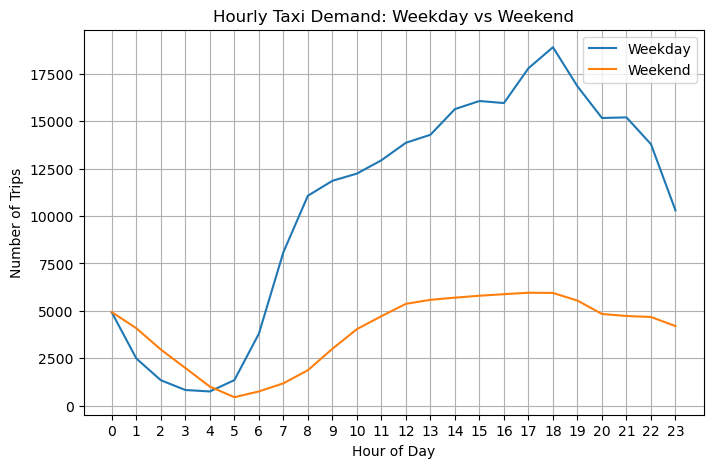

In [284]:

plt.figure(figsize=(8,5))

plt.plot(weekday_trips['pickup_hour'], weekday_trips['trip_count'], label='Weekday')
plt.plot(weekend_trips['pickup_hour'], weekend_trips['trip_count'], label='Weekend')

plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.title('Hourly Taxi Demand: Weekday vs Weekend')

plt.xticks(range(0,24))
plt.legend()
plt.grid(True)

plt.show()

In [285]:
# Find top 10 pickup and dropoff zones

trip_zone_df = trip_zone_df.merge(zones_unique[["LocationID","zone"]], left_on = "DOLocationID", right_on = "LocationID", how = "left")

In [286]:
trip_zone_df.rename(columns={'zone_x': 'pickup_zone','zone_y': 'dropoff_zone'}, inplace=True)

In [287]:
top_pickupzone = trip_zone_df.groupby("pickup_zone").size().sort_values(ascending=False).head(10)
top_pickupzone

pickup_zone
JFK Airport                     18698
Upper East Side South           16986
Midtown Center                  16741
Upper East Side North           15154
Midtown East                    12917
LaGuardia Airport               12475
Penn Station/Madison Sq West    12312
Times Sq/Theatre District       11872
Lincoln Square East             11779
Murray Hill                     10568
dtype: int64

In [288]:
top_dropoffzone = trip_zone_df.groupby("dropoff_zone").size().sort_values(ascending=False).head(10)
top_dropoffzone

dropoff_zone
Upper East Side North        15933
Upper East Side South        15138
Midtown Center               13959
Times Sq/Theatre District    10845
Murray Hill                  10648
Midtown East                 10164
Lincoln Square East          10088
Upper West Side South         9915
Lenox Hill West               9385
East Chelsea                  9076
dtype: int64

In [289]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
pickup_counts = trip_zone_df.groupby("pickup_zone").size().reset_index(name = "pickups")


In [290]:
dropoff_counts = trip_zone_df.groupby("dropoff_zone").size().reset_index(name = "dropoffs")

In [291]:
zone_ratio = pickup_counts.merge(dropoff_counts, left_on = "pickup_zone", right_on = "dropoff_zone", how = "outer")

In [292]:
zone_ratio["pickups"] = zone_ratio["pickups"].fillna(0)

In [293]:
zone_ratio["zone"] = zone_ratio["pickup_zone"].fillna(zone_ratio["dropoff_zone"])

In [294]:
zone_ratio = zone_ratio[["zone", "pickups", "dropoffs"]]

In [295]:
zone_ratio["pick_drop_ratio"] = (zone_ratio["pickups"]/zone_ratio["dropoffs"]).round(2)

In [296]:
highest_ratio = zone_ratio.sort_values("pick_drop_ratio", ascending = False).head(10)
print(highest_ratio)

                             zone  pickups  dropoffs  pick_drop_ratio
66                  East Elmhurst   1626.0       176             9.24
120                   JFK Airport  18698.0      3737             5.00
129             LaGuardia Airport  12475.0      4193             2.98
178  Penn Station/Madison Sq West  12312.0      7955             1.55
40                   Central Park   6095.0      4348             1.40
105       Greenwich Village South   4619.0      3406             1.36
239                  West Village   7990.0      5875             1.36
153                  Midtown East  12917.0     10164             1.27
152                Midtown Center  16741.0     13959             1.20
224                      Union Sq   9730.0      8186             1.19


In [297]:
lowest_ratio = zone_ratio.sort_values("pick_drop_ratio").head(10)
print(lowest_ratio)

                            zone  pickups  dropoffs  pick_drop_ratio
0        Allerton/Pelham Gardens      0.0        17              0.0
113                       Hollis      0.0        20              0.0
110                   Highbridge      0.0        49              0.0
109  Heartland Village/Todt Hill      0.0         9              0.0
106          Grymes Hill/Clifton      0.0         1              0.0
102          Green-Wood Cemetery      0.0         4              0.0
101                  Great Kills      0.0         4              0.0
100                    Gravesend      0.0        19              0.0
96                     Glen Oaks      0.0        26              0.0
114                    Homecrest      0.0        49              0.0


In [298]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones

night_df = trip_zone_df[trip_zone_df["pickup_hour"].isin([23,0,1,2,3,4,5])]

In [299]:
night_pickups = night_df.groupby("pickup_zone").size().reset_index(name = "trip_counts").sort_values("trip_counts", ascending=False)

In [300]:
night_pickups.head(10)

,pickup_zone,trip_counts
40,East Village,3011
63,JFK Airport,2827
137,West Village,2492
22,Clinton East,2017
78,Lower East Side,1889
123,Times Sq/Theatre District,1683
57,Greenwich Village South,1652
102,Penn Station/Madison Sq West,1357
70,LaGuardia Airport,1231
90,Midtown South,1185


In [301]:
night_dropoffs = night_df.groupby("dropoff_zone").size().reset_index(name = "trip_counts").sort_values("trip_counts", ascending=False)

In [302]:
night_dropoffs.head(10)

,dropoff_zone,trip_counts
70,East Village,1667
41,Clinton East,1397
152,Murray Hill,1262
93,Gramercy,1153
59,East Chelsea,1126
124,Lenox Hill West,1053
236,Yorkville West,992
222,West Village,899
203,Sutton Place/Turtle Bay North,871
204,Times Sq/Theatre District,856


In [303]:
# Filter for night hours (11 PM to 5 AM)

In [304]:
day_df = trip_zone_df[(trip_zone_df["pickup_hour"] > 5) & (trip_zone_df["pickup_hour"] < 23)]

In [305]:
day_revenue = day_df["total_amount"].sum()
day_revenue

np.float64(8842368.34)

In [306]:
night_revenue = night_df["total_amount"].sum()
night_revenue

np.float64(1215503.15)

In [307]:
total_revenue = day_revenue + night_revenue
total_revenue

np.float64(10057871.49)

In [308]:
day_share = ((day_revenue/total_revenue)*100).round(2)
day_share

np.float64(87.91)

In [309]:
night_share = ((night_revenue/total_revenue)*100).round(2)
night_share

np.float64(12.09)

##### Pricing Strategy

In [310]:
# Analyse the fare per mile per passenger for different passenger counts
fare_df = trip_zone_df.copy()


In [311]:
fare_df["fare_per_mile"] = fare_df["fare_amount"]/fare_df["trip_distance"]

In [312]:
avg_fare = fare_df.groupby("passenger_count")["fare_per_mile"].mean()

In [313]:
avg_fare

passenger_count
1.0    10.646038
2.0    12.712888
3.0    12.800042
4.0    16.775197
5.0     7.857008
6.0     7.736936
Name: fare_per_mile, dtype: float64

In [314]:
fare_per_passenger = avg_fare/avg_fare.index
fare_per_passenger

passenger_count
1.0    10.646038
2.0     6.356444
3.0     4.266681
4.0     4.193799
5.0     1.571402
6.0     1.289489
dtype: float64

In [315]:
# Compare the average fare per mile for different days and for different times of the day

avg_per_hour = fare_df.groupby("pickup_hour")["fare_per_mile"].mean()

In [316]:
avg_per_hour

pickup_hour
0     11.453926
1     10.817632
2      9.036978
3      9.175086
4     16.330004
5     11.117941
6     12.809720
7     10.338797
8      9.749610
9      9.341832
10    10.568517
11    10.755380
12    11.842224
13    11.766109
14    12.839344
15    10.827533
16    13.803151
17    12.127986
18    11.228622
19    11.230395
20     9.486288
21     9.190944
22    11.311766
23     9.975877
Name: fare_per_mile, dtype: float64

In [317]:
avg_dayofweek = fare_df.groupby("day_of_week")["fare_per_mile"].mean()

In [318]:
avg_dayofweek

day_of_week
Friday       10.563727
Monday       10.862624
Saturday     10.843699
Sunday       12.116404
Thursday     12.261604
Tuesday      10.160326
Wednesday    11.002303
Name: fare_per_mile, dtype: float64

In [319]:
# Compare fare per mile for different vendors

vendor_fare = fare_df.groupby(["VendorID","pickup_hour"])["fare_per_mile"].mean().reset_index(name="avg_fare")
print(vendor_fare)

    VendorID  pickup_hour   avg_fare
0          1            0   6.700842
1          1            1   7.130758
2          1            2   7.026171
3          1            3   6.423107
4          1            4   6.773307
5          1            5   7.467460
6          1            6   6.310515
7          1            7   7.102952
8          1            8   8.054310
9          1            9   8.107724
10         1           10   8.166181
11         1           11   8.585020
12         1           12   8.707682
13         1           13   8.495122
14         1           14   8.748116
15         1           15   8.625748
16         1           16   8.829687
17         1           17   8.493624
18         1           18   8.446630
19         1           19   7.946493
20         1           20   7.348051
21         1           21   7.310122
22         1           22   6.940687
23         1           23   6.689639
24         2            0  12.793826
25         2            1  11.780257
2

In [320]:
# Defining distance tiers

def assign_tier(distance):
    if distance < 2:
        return "short (0-2 miles)"
    elif distance <= 5:
        return "medium (2-5 miles)"
    else:
        return "Long (5+ miles)"

fare_df['distance_tier'] = fare_df['trip_distance'].apply(assign_tier)


In [321]:
print(fare_df['distance_tier'].value_counts())

distance_tier
short (0-2 miles)     192880
medium (2-5 miles)     98350
Long (5+ miles)        59419
Name: count, dtype: int64


In [322]:
tier_fare = fare_df.groupby(["VendorID", "distance_tier"])["fare_per_mile"].mean().round(2)
tier_fare

VendorID  distance_tier     
1         Long (5+ miles)        4.45
          medium (2-5 miles)     6.42
          short (0-2 miles)      9.79
2         Long (5+ miles)        4.50
          medium (2-5 miles)     6.55
          short (0-2 miles)     17.42
Name: fare_per_mile, dtype: float64

##### Customer Experience and Other Factors

In [323]:
#  Analyze tip percentages based on distances, passenger counts and pickup times

fare_df["tip_percent"] = ((fare_df["tip_amount"]/fare_df["fare_amount"])*100).round(2)

In [324]:
tip_df = fare_df.copy()

In [325]:
tip_distance = tip_df.groupby("distance_tier")["tip_percent"].mean().round(2)
tip_distance

distance_tier
Long (5+ miles)       16.84
medium (2-5 miles)    18.91
short (0-2 miles)     22.59
Name: tip_percent, dtype: float64

In [326]:
tip_passengcount = tip_df.groupby("passenger_count")["tip_percent"].mean().round(2)
tip_passengcount

passenger_count
1.0    20.91
2.0    19.75
3.0    18.98
4.0    17.39
5.0    20.93
6.0    20.67
Name: tip_percent, dtype: float64

In [327]:
tip_pickuphour = tip_df.groupby("pickup_hour")["tip_percent"].mean().round(2)
tip_pickuphour

pickup_hour
0     20.59
1     21.27
2     20.40
3     20.53
4     18.06
5     17.69
6     19.66
7     19.94
8     20.25
9     19.83
10    19.54
11    19.29
12    19.43
13    19.20
14    19.42
15    19.11
16    21.12
17    21.96
18    22.30
19    22.23
20    21.45
21    21.56
22    21.42
23    20.70
Name: tip_percent, dtype: float64

In [328]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%

low_tip = tip_df[tip_df["tip_percent"] < 10]
high_tip = tip_df[tip_df["tip_percent"] > 25]

In [329]:
low_tip.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,quarter,trip_duration,LocationID_x,OBJECTID,Shape_Leng,Shape_Area,trip_duration_hr,LocationID_y,fare_per_mile,tip_percent
count,89476.000000,89476,89476,89476.000000,89476.000000,89476.000000,89476.000000,89476.000000,89476.000000,89476.000000,...,89476.000000,89476.000000,89476.000000,89476.000000,89476.000000,89476.000000,89476.000000,88628.000000,89476.000000,89476.000000
mean,1.745105,2023-07-01 16:56:11.350350,2023-07-01 17:13:28.522162,1.442521,3.823424,1.082849,160.865361,158.588560,1.779539,21.222145,...,2.502023,17.286197,160.865361,160.865361,0.062807,0.000277,0.288103,157.579546,16.393911,1.119343
min,1.000000,2023-01-01 00:04:42,2023-01-01 00:13:09,1.000000,0.010000,1.000000,1.000000,1.000000,1.000000,0.010000,...,1.000000,0.016667,1.000000,1.000000,0.024696,0.000034,0.000278,1.000000,0.000714,0.000000
25%,1.000000,2023-04-03 17:00:15.250000,2023-04-03 17:32:46.500000,1.000000,1.070000,1.000000,132.000000,107.000000,1.000000,9.300000,...,2.000000,8.033333,132.000000,132.000000,0.035772,0.000058,0.133889,100.000000,5.486074,0.000000
50%,2.000000,2023-06-27 17:30:17.500000,2023-06-27 17:45:55,1.000000,1.860000,1.000000,161.000000,161.000000,2.000000,14.200000,...,2.000000,13.233333,161.000000,161.000000,0.042525,0.000094,0.220556,161.000000,7.153846,0.000000
75%,2.000000,2023-10-02 10:32:28.250000,2023-10-02 10:53:49.750000,2.000000,3.880000,1.000000,230.000000,231.000000,2.000000,24.000000,...,4.000000,21.900000,230.000000,230.000000,0.054890,0.000167,0.365000,230.000000,9.307692,0.000000
max,2.000000,2023-12-31 23:54:03,2023-12-31 23:57:08,6.000000,76.730000,5.000000,263.000000,265.000000,4.000000,386.600000,...,4.000000,177.566667,263.000000,263.000000,0.290556,0.002196,2.959444,263.000000,15000.000000,9.990000
std,0.435805,NaN,NaN,0.919245,5.040477,0.399173,63.233768,70.943706,0.599014,20.217488,...,1.114013,14.148225,63.233768,63.233768,0.057926,0.000537,0.235804,70.514411,208.962593,2.690189


In [330]:
high_tip.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,quarter,trip_duration,LocationID_x,OBJECTID,Shape_Leng,Shape_Area,trip_duration_hr,LocationID_y,fare_per_mile,tip_percent
count,159340.000000,159340,159340,159340.000000,159340.000000,159340.000000,159340.000000,159340.000000,159340.000000,159340.000000,...,159340.000000,159340.000000,159340.000000,159340.000000,159340.000000,159340.000000,159340.000000,158840.000000,159340.000000,159340.000000
mean,1.752523,2023-07-01 06:38:49.878341,2023-07-01 06:51:03.296246,1.366662,2.291636,1.014397,168.042940,168.017064,1.000063,14.367479,...,2.496423,12.223632,168.042940,168.042940,0.047740,0.000137,0.203727,167.714002,8.533134,32.148349
min,1.000000,2023-01-01 00:05:27,2023-01-01 00:09:40,1.000000,0.010000,1.000000,1.000000,1.000000,1.000000,3.000000,...,1.000000,0.066667,1.000000,1.000000,0.024696,0.000034,0.001111,1.000000,0.588235,25.010000
25%,2.000000,2023-03-30 21:00:06.250000,2023-03-30 21:11:24.250000,1.000000,0.930000,1.000000,138.000000,137.000000,1.000000,7.900000,...,1.000000,6.533333,138.000000,138.000000,0.035772,0.000058,0.108889,137.000000,6.208333,27.187500
50%,2.000000,2023-06-24 18:45:17,2023-06-24 18:58:46,1.000000,1.430000,1.000000,162.000000,163.000000,1.000000,11.400000,...,2.000000,10.066667,162.000000,162.000000,0.042213,0.000077,0.167778,163.000000,7.560976,29.920000
75%,2.000000,2023-10-06 18:40:33.500000,2023-10-06 18:54:52.250000,1.000000,2.230000,1.000000,234.000000,236.000000,1.000000,14.900000,...,4.000000,14.733333,234.000000,234.000000,0.049064,0.000114,0.245556,236.000000,9.312946,33.980000
max,2.000000,2023-12-31 23:53:18,2024-01-01 00:10:03,6.000000,56.500000,5.000000,263.000000,265.000000,4.000000,332.700000,...,4.000000,155.266667,263.000000,263.000000,0.245479,0.002038,2.587778,263.000000,14315.000000,2966.670000
std,0.431548,NaN,NaN,0.867234,2.889873,0.161131,63.028149,66.728795,0.011750,11.545509,...,1.136339,9.193809,63.028149,63.028149,0.027429,0.000223,0.153230,66.614397,45.087985,16.696746


In [331]:
# See how passenger count varies across hours and days

hourly_passenger = trip_zone_df.groupby("pickup_hour")["passenger_count"].mean()
hourly_passenger

pickup_hour
0     1.415135
1     1.454753
2     1.434296
3     1.444722
4     1.371347
5     1.304714
6     1.243440
7     1.282970
8     1.303578
9     1.327770
10    1.367642
11    1.373302
12    1.384064
13    1.382920
14    1.400525
15    1.430975
16    1.414897
17    1.392364
18    1.383730
19    1.397561
20    1.402429
21    1.426766
22    1.442772
23    1.445372
Name: passenger_count, dtype: float64

In [332]:
weekday_passenger = trip_zone_df.groupby("day_of_week")["passenger_count"].mean()
weekday_passenger

day_of_week
Friday       1.412935
Monday       1.365144
Saturday     1.484786
Sunday       1.470163
Thursday     1.348774
Tuesday      1.338494
Wednesday    1.336839
Name: passenger_count, dtype: float64

In [333]:
# How does passenger count vary across zones

zone_passenger = trip_zone_df.groupby("pickup_zone")["passenger_count"].mean().reset_index()

In [334]:
zone_passenger.sort_values("passenger_count", ascending=False).head(10)

,pickup_zone,passenger_count
90,Jamaica Estates,3.500000
47,Dyker Heights,3.000000
32,Claremont/Bathgate,2.500000
1,Arrochar/Fort Wadsworth,2.250000
168,Sunset Park West,2.100000
40,Corona,2.076923
111,Maspeth,2.000000
125,Murray Hill-Queens,2.000000
129,Oakland Gardens,2.000000
140,Queens Village,2.000000


In [335]:
zone_passenger.sort_values("passenger_count", ascending=True).head(10)

,pickup_zone,passenger_count
121,Morrisania/Melrose,1.0
155,Soundview/Bruckner,1.0
72,Glendale,1.0
181,Van Cortlandt Village,1.0
180,Van Cortlandt Park,1.0
31,City Island,1.0
69,Forest Park/Highland Park,1.0
36,Co-Op City,1.0
175,University Heights/Morris Heights,1.0
39,Columbia Street,1.0


In [336]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.

zones_trip_df = zones_trip_df.merge(zone_passenger, left_on="zone", right_on="pickup_zone", how = "left")

In [337]:
zones_trip_df.drop("pickup_zone", axis = 1, inplace=True)

In [338]:
zones_trip_df["passenger_count"] = zones_trip_df["passenger_count"].fillna(0)

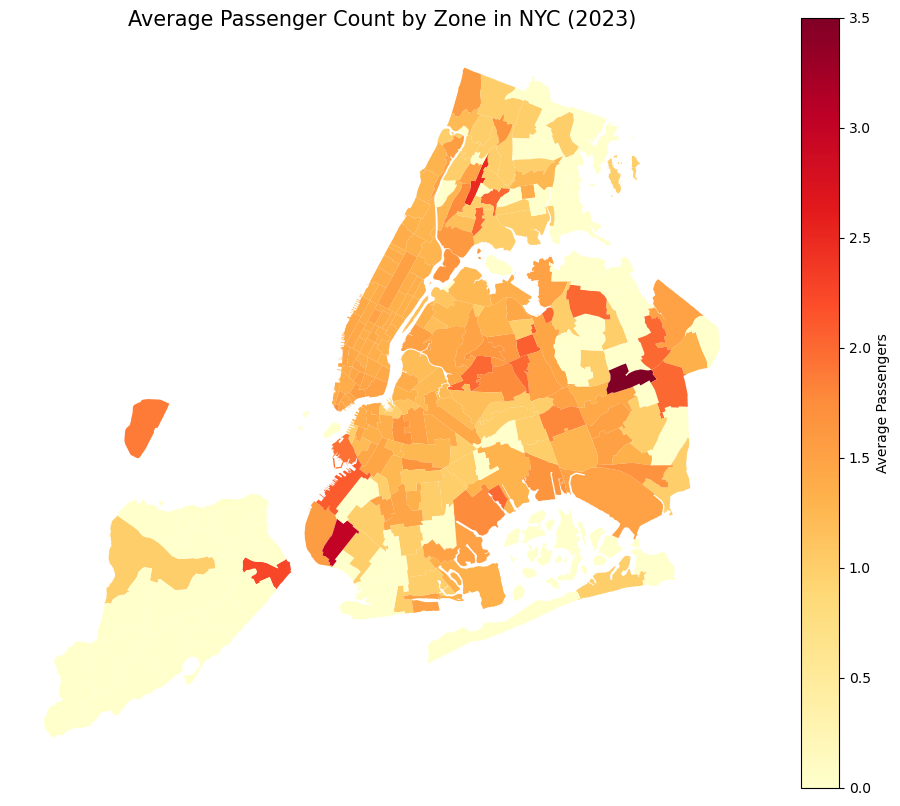

In [339]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

zones_trip_df.plot(
    column='passenger_count',
    ax=ax,
    legend=True,
    cmap='YlOrRd',
    legend_kwds={'label': 'Average Passengers','orientation': 'vertical'})

ax.set_title('Average Passenger Count by Zone in NYC (2023)', fontsize=15)
ax.axis('off')
plt.show()

In [340]:
# How often is each surcharge applied?

trip_zone_df['extra_charge_flag'] = (
    (trip_zone_df['extra'] > 0) | (trip_zone_df['congestion_surcharge'] > 0) | (trip_zone_df['airport_fee'] > 0) | (trip_zone_df['tolls_amount'] > 0)
)

In [341]:
trip_zone_df['extra_charge_flag'].value_counts()

extra_charge_flag
True     346476
False      4173
Name: count, dtype: int64

In [342]:
extra_pickup = trip_zone_df.groupby("pickup_zone")['extra_charge_flag'].mean()*100
extra_pickup

pickup_zone
Alphabet City              100.000000
Arrochar/Fort Wadsworth    100.000000
Astoria                     60.305344
Auburndale                  50.000000
Baisley Park                87.640449
                              ...    
Woodhaven                    0.000000
Woodside                    71.153846
World Trade Center          99.836779
Yorkville East              99.977925
Yorkville West              99.675994
Name: extra_charge_flag, Length: 198, dtype: float64

In [343]:
extra_dropoff = trip_zone_df.groupby("dropoff_zone")['extra_charge_flag'].mean()*100
extra_dropoff

dropoff_zone
Allerton/Pelham Gardens    100.000000
Alphabet City              100.000000
Arden Heights              100.000000
Arrochar/Fort Wadsworth    100.000000
Astoria                     94.806517
                              ...    
Woodlawn/Wakefield          93.939394
Woodside                    95.272727
World Trade Center          99.880096
Yorkville East              99.909420
Yorkville West              99.526066
Name: extra_charge_flag, Length: 254, dtype: float64

In [344]:
extra_hour = trip_zone_df.groupby("pickup_hour")['extra_charge_flag'].mean()*100
extra_hour

pickup_hour
0     99.898426
1     99.771481
2     99.650513
3     99.465050
4     99.770774
5     99.102132
6     97.001103
7     97.042953
8     97.209985
9     97.853008
10    97.880054
11    97.865716
12    98.102812
13    97.866237
14    98.036735
15    97.933147
16    99.276689
17    99.334905
18    99.444802
19    99.455090
20    99.925041
21    99.959872
22    99.913373
23    99.924127
Name: extra_charge_flag, dtype: float64

## Conclusion


### Final Insights and Recommendations



Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

### Routing and Dispatching Recommendations

Based on our EDA of 2023 NYC Yellow Taxi data, here are key recommendations:

1. Peak Hour Dispatching:
- The busiest hours are 5PM-7PM with 23,000+ trips per hour
- Dispatch maximum cabs during 5PM-10PM on weekdays to meet evening demand
- Reduce fleet during 3AM-5AM which has the lowest demand (under 2,000 trips/hour)

2. Weekday vs Weekend Routing:
- Weekdays show a classic double peak - morning rush (8AM-9AM) and evening rush (5PM-7PM)
- Weekends show a single gradual peak starting from noon lasting till midnight
- Route cabs toward business districts on weekday mornings and entertainment zones on weekend nights

3. Reducing Empty Return Trips:
- High pickup/dropoff ratio zones like JFK (5.0), LaGuardia (2.98) and East Elmhurst (9.24) 
  always need cabs available as outbound demand far exceeds inbound
- After dropping passengers in low ratio zones like Astoria (0.13), 
  immediately redirect cabs back to high demand zones to avoid empty waiting

4. Night Operations:
- Focus night dispatching (11PM-5AM) around East Village, West Village, 
  Clinton East and Lower East Side - the top nightlife pickup zones
- Keep cabs near JFK for late night flight arrivals

### Cab Positioning Strategy

1. Zone Based Positioning:
- Top 3 pickup zones are JFK Airport (18,698 trips), Upper East Side South (16,986) 
  and Midtown Center (16,741) - always maintain cab presence in these zones
- Manhattan zones dominate overall pickup volumes - concentrate fleet in Manhattan 
  during daytime hours
- Outer boroughs like Queens and Brooklyn need larger capacity vehicles as they 
  have higher average passenger counts

2. Time Based Positioning:
- Early morning (5AM-9AM): Position cabs near business districts, Penn Station 
  and Grand Central for commuter demand
- Afternoon (12PM-3PM): Concentrate around Midtown, tourist zones and shopping areas
- Evening (5PM-10PM): Spread across Midtown, Upper East Side and entertainment zones
- Late night (11PM-5AM): Focus on East Village, West Village and airport zones

3. Borough Strategy:
- Manhattan generates majority of revenue so always prioritize Manhattan coverage
- Queens is important for airport traffic so maintain dedicated airport fleet for Queens
- Bronx and Staten Island have lowest demand - minimal fleet needed there

### Data-Driven Pricing Strategy Recommendations

1. Dynamic Surge Pricing:
- Fare per mile is naturally highest at 4AM ($16.33/mile) and during 
  rush hours (2PM, 4PM, 6PM)
- Thursday and Sunday have highest fare per mile by day -
  apply mild surge pricing on these days
- Evening hours (6PM-10PM) show highest tip percentages (21-22%) indicating 
  high customer satisfaction
    
2. Vendor Strategy:
- VeriFone charges significantly higher fare per mile than Creative Mobile,
  especially for short trips ($17.42 vs $9.79 per mile)
- Since 55% of NYC trips are short (under 2 miles), partnering with VeriFone 
  would maximize revenue on the majority of trips
- For long distance trips both vendors are nearly identical ($4.45 vs $4.50) 
  so vendor choice matters less for airport and outer borough runs

3. Group Ride Pricing:
- Fare per mile per passenger decreases as group size increases,
  a small increase in minimum fare can increase the profitability
- Introduce group ride discounts for 3-6 passengers to incentivize shared rides
- This increases vehicle utilization while maintaining competitive per-person rates
- Target outer borough zones with cab having larger capacity where average passenger count is highest (2-3.5)

4. Distance Based Pricing:
- Short trips (0-2 miles) already generate highest fare per mile naturally
- Long trips (5+ miles) generate lowest fare per mile so a fixed rate pricing would provide more predictable revenue

5. Surcharge Optimization:
- 98.8% of trips already have surcharges applied
- Airport zones generate highest surcharge revenue - maintain airport fee structure as it significantly boosts per trip revenue
- Congestion surcharge in Manhattan is consistently applied